# **Bai tap — Phan loai anh voi cac mo hinh hoc sau co ban**

**Mon hoc:** Hoc sau va ung dung trong thi giac may tinh (CO5085)

**Giang vien:** Le Thanh Sach

---

## Muc luc
1. Cai dat & Import
2. Tap du lieu & EDA
3. Phan 1 — Xay dung cac mo hinh phan loai
4. Phan 2 — Huan luyen, danh gia va so sanh
5. Phan 3 — Tu hien thuc TransformerEncoder va ViT
6. Phan 4 — Cac kien truc ket hop va cach embed anh khac nhau
7. Phan 5 — Mo hinh phan loai dua tren LSTM/GRU
8. Tong hop ket qua & So sanh

## 1. Cai dat & Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import time
import math
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Kiem tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Su dung device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Su dung device: cuda
GPU: Tesla T4


### Hyperparameters chung

In [ ]:
# ============ CAU HINH CHUNG ============
# Ban co the thay doi dataset tai day: 'FashionMNIST', 'MNIST', 'CIFAR10'
DATASET_NAME = 'FashionMNIST'

BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.1  # 10% training set lam validation

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 2. Tap du lieu & EDA

**Ly do chon Fashion-MNIST:**
- 10 lop, 60000 mau train, 10000 mau test
- Kich thuoc 28x28 grayscale, phu hop voi pham vi bai tap
- Do kho vua phai, cao hon MNIST nhung van chay nhanh tren Colab

In [ ]:
def get_dataset(name='FashionMNIST'):
    """Tai va chuan bi dataset."""
    if name == 'CIFAR10':
        transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2470, 0.2435, 0.2616))
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2470, 0.2435, 0.2616))
        ])
        train_full = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=True, transform=transform_train)
        test_set = torchvision.datasets.CIFAR10(
            root='./data', train=False, download=True, transform=transform_test)
        num_classes = 10
        class_names = ['airplane','automobile','bird','cat','deer',
                       'dog','frog','horse','ship','truck']
        in_channels = 3
        img_size = 32
    else:
        dataset_cls = getattr(torchvision.datasets, name)
        transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_full = dataset_cls(
            root='./data', train=True, download=True, transform=transform_train)
        test_set = dataset_cls(
            root='./data', train=False, download=True, transform=transform_test)
        num_classes = 10
        in_channels = 1
        img_size = 28
        if name == 'FashionMNIST':
            class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                           'Sandal','Shirt','Sneaker','Bag','Ankle boot']
        else:
            class_names = [str(i) for i in range(10)]

    # Chia train/val
    val_size = int(len(train_full) * VAL_RATIO)
    train_size = len(train_full) - val_size
    train_set, val_set = random_split(
        train_full, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED))

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)

    info = {
        'num_classes': num_classes,
        'class_names': class_names,
        'in_channels': in_channels,
        'img_size': img_size,
        'train_size': train_size,
        'val_size': val_size,
        'test_size': len(test_set)
    }
    return train_loader, val_loader, test_loader, info

train_loader, val_loader, test_loader, data_info = get_dataset(DATASET_NAME)
print(f"Dataset: {DATASET_NAME}")
print(f"Train: {data_info['train_size']}, Val: {data_info['val_size']}, Test: {data_info['test_size']}")
print(f"So lop: {data_info['num_classes']}")
print(f"Kich thuoc anh: {data_info['img_size']}x{data_info['img_size']}, Channels: {data_info['in_channels']}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]

Dataset: FashionMNIST
Train: 54000, Val: 6000, Test: 10000
So lop: 10
Kich thuoc anh: 28x28, Channels: 1


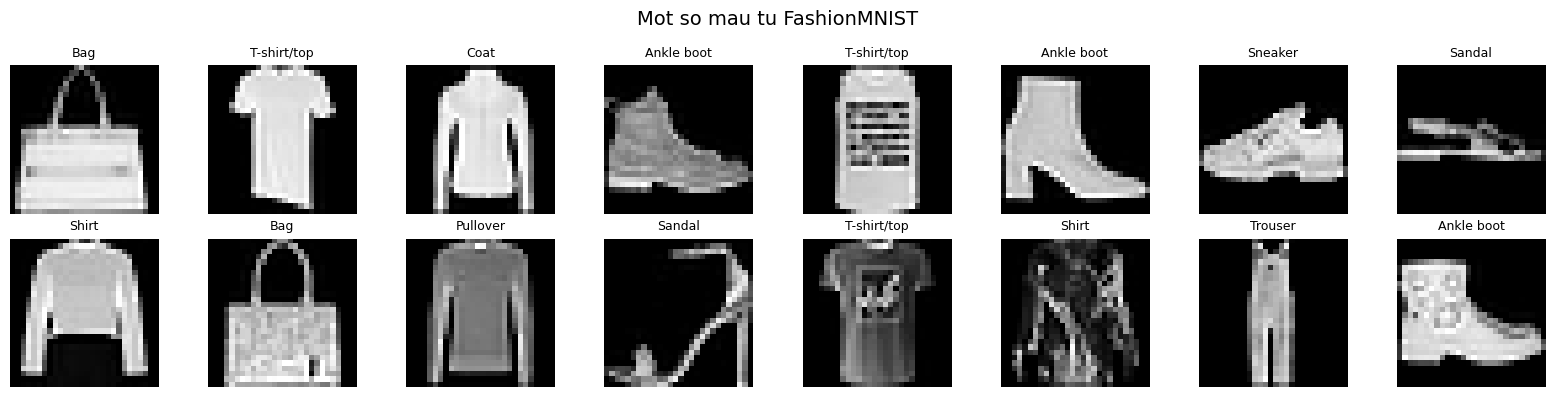

In [ ]:
# ============ EDA: Hien thi mot so mau ============
def show_samples(loader, class_names, n=16):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            break
        img = images[i]
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            img = img.permute(1, 2, 0)
            img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + \
                  torch.tensor([0.4914, 0.4822, 0.4465])
            img = img.clamp(0, 1)
            ax.imshow(img)
        ax.set_title(class_names[labels[i]], fontsize=9)
        ax.axis('off')
    plt.suptitle(f'Mot so mau tu {DATASET_NAME}', fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(train_loader, data_info['class_names'])

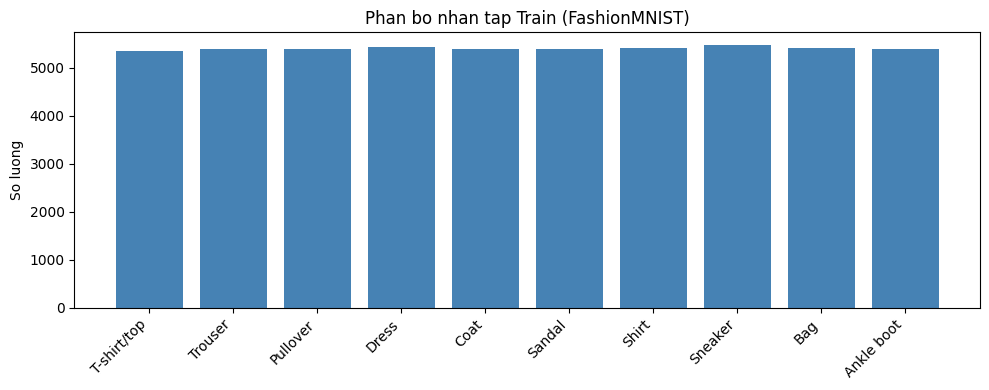

In [ ]:
# ============ EDA: Phan bo nhan ============
def plot_label_distribution(loader, class_names, title='Phan bo nhan'):
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.numpy())
    counts = np.bincount(all_labels, minlength=len(class_names))
    plt.figure(figsize=(10, 4))
    plt.bar(class_names, counts, color='steelblue')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('So luong')
    plt.tight_layout()
    plt.show()

plot_label_distribution(train_loader, data_info['class_names'],
                        f'Phan bo nhan tap Train ({DATASET_NAME})')

---
## 3. Phan 1 — Xay dung cac mo hinh phan loai

Xay dung 4 mo hinh:
1. **Softmax Regression** — Mo hinh tuyen tinh
2. **MLP** — Mang fully connected nhieu tang
3. **CNN** — Mang tich chap
4. **ViT (PyTorch built-in)** — Vision Transformer su dung khoi co san

### 3.1 Softmax Regression

In [ ]:
class SoftmaxRegression(nn.Module):
    """Mo hinh tuyen tinh: flatten anh -> linear -> softmax."""
    def __init__(self, in_channels, img_size, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_channels * img_size * img_size, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x  # CrossEntropyLoss da bao gom softmax

# Test
model_test = SoftmaxRegression(data_info['in_channels'],
                                data_info['img_size'],
                                data_info['num_classes'])
print(f"SoftmaxRegression — Tong tham so: {sum(p.numel() for p in model_test.parameters()):,}")

SoftmaxRegression — Tong tham so: 7,850


### 3.2 MLP (Multi-Layer Perceptron)

In [ ]:
class MLP(nn.Module):
    """MLP: Flatten -> [Linear -> BN -> ReLU -> Dropout] x N -> Linear."""
    def __init__(self, in_channels, img_size, num_classes,
                 hidden_dims=[512, 256], dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        input_dim = in_channels * img_size * img_size

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

model_test = MLP(data_info['in_channels'], data_info['img_size'],
                 data_info['num_classes'])
print(f"MLP — Tong tham so: {sum(p.numel() for p in model_test.parameters()):,}")

MLP — Tong tham so: 537,354


### 3.3 CNN (Convolutional Neural Network)

In [ ]:
class SimpleCNN(nn.Module):
    """CNN don gian: [Conv -> BN -> ReLU -> Pool] x 3 -> FC."""
    def __init__(self, in_channels, img_size, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_test = SimpleCNN(data_info['in_channels'], data_info['img_size'],
                        data_info['num_classes'])
print(f"SimpleCNN — Tong tham so: {sum(p.numel() for p in model_test.parameters()):,}")

SimpleCNN — Tong tham so: 94,410


### 3.4 Vision Transformer (ViT) — Dung khoi PyTorch co san

In [ ]:
class ViT_Builtin(nn.Module):
    """
    Vision Transformer su dung nn.TransformerEncoder co san.
    Patch embedding -> [CLS] token + positional encoding -> Transformer -> Classification.
    """
    def __init__(self, in_channels, img_size, num_classes,
                 patch_size=7, embed_dim=128, num_heads=4,
                 num_layers=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        assert img_size % patch_size == 0, \
            f"img_size ({img_size}) phai chia het cho patch_size ({patch_size})"

        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        # Patch embedding
        self.patch_embed = nn.Sequential(
            nn.Unfold(kernel_size=patch_size, stride=patch_size),
        )
        self.linear_proj = nn.Linear(patch_dim, embed_dim)

        # [CLS] token va positional embedding
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # Transformer Encoder (dung khoi co san)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)           # (B, patch_dim, num_patches)
        x = x.transpose(1, 2)             # (B, num_patches, patch_dim)
        x = self.linear_proj(x)           # (B, num_patches, embed_dim)

        # Them [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, num_patches+1, embed_dim)

        # Them positional embedding
        x = x + self.pos_embed
        x = self.dropout(x)

        # Transformer encoder
        x = self.transformer(x)

        # Lay [CLS] token -> classify
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x

model_test = ViT_Builtin(data_info['in_channels'], data_info['img_size'],
                          data_info['num_classes'])
print(f"ViT (built-in) — Tong tham so: {sum(p.numel() for p in model_test.parameters()):,}")

ViT (built-in) — Tong tham so: 540,170


/tmp/ipykernel_1977/196319873.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


---
## 4. Phan 2 — Huan luyen, danh gia va so sanh

Tu viet training loop voi PyTorch: forward -> loss -> backward -> optimizer step

In [ ]:
# ============ TRAINING LOOP ============
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Huan luyen mot epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Thong ke
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Danh gia tren tap val/test."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, num_epochs, lr, device,
                weight_decay=1e-4, scheduler_type='cosine'):
    """
    Huan luyen day du: training loop + validation + logging.
    Tra ve history (loss, acc) qua cac epoch.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=weight_decay)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs)
    else:
        scheduler = None

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:>2}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time
    history['total_time'] = total_time
    history['best_val_acc'] = best_val_acc
    print(f"  Done! Time: {total_time:.1f}s | "
          f"Best Val Acc: {best_val_acc:.4f}")
    return history

In [ ]:
# ============ HUAN LUYEN 4 MO HINH ============
results = {}

# --- 1. Softmax Regression ---
print("="*60)
print("[1/4] Huan luyen Softmax Regression")
print("="*60)
model_softmax = SoftmaxRegression(
    data_info['in_channels'], data_info['img_size'], data_info['num_classes'])
results['Softmax'] = train_model(
    model_softmax, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

[1/4] Huan luyen Softmax Regression
  Epoch [ 1/20] Train Loss: 0.7060 | Train Acc: 0.7615 | Val Loss: 0.6080 | Val Acc: 0.7907
  Epoch [ 5/20] Train Loss: 0.5082 | Train Acc: 0.8274 | Val Loss: 0.5343 | Val Acc: 0.8167
  Epoch [10/20] Train Loss: 0.4841 | Train Acc: 0.8349 | Val Loss: 0.5365 | Val Acc: 0.8157
  Epoch [15/20] Train Loss: 0.4720 | Train Acc: 0.8405 | Val Loss: 0.5142 | Val Acc: 0.8235
  Epoch [20/20] Train Loss: 0.4673 | Train Acc: 0.8425 | Val Loss: 0.5086 | Val Acc: 0.8280
  Done! Time: 270.4s | Best Val Acc: 0.8288


In [ ]:
# --- 2. MLP ---
print("="*60)
print("[2/4] Huan luyen MLP")
print("="*60)
model_mlp = MLP(data_info['in_channels'], data_info['img_size'],
                data_info['num_classes'])
results['MLP'] = train_model(
    model_mlp, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

[2/4] Huan luyen MLP
  Epoch [ 1/20] Train Loss: 0.5270 | Train Acc: 0.8131 | Val Loss: 0.3964 | Val Acc: 0.8545
  Epoch [ 5/20] Train Loss: 0.3371 | Train Acc: 0.8754 | Val Loss: 0.3361 | Val Acc: 0.8778
  Epoch [10/20] Train Loss: 0.2790 | Train Acc: 0.8964 | Val Loss: 0.3021 | Val Acc: 0.8887
  Epoch [15/20] Train Loss: 0.2250 | Train Acc: 0.9164 | Val Loss: 0.2787 | Val Acc: 0.8985
  Epoch [20/20] Train Loss: 0.2006 | Train Acc: 0.9253 | Val Loss: 0.2667 | Val Acc: 0.9030
  Done! Time: 275.0s | Best Val Acc: 0.9030


In [ ]:
# --- 3. CNN ---
print("="*60)
print("[3/4] Huan luyen CNN")
print("="*60)
model_cnn = SimpleCNN(data_info['in_channels'], data_info['img_size'],
                       data_info['num_classes'])
results['CNN'] = train_model(
    model_cnn, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

[3/4] Huan luyen CNN
  Epoch [ 1/20] Train Loss: 0.7397 | Train Acc: 0.7577 | Val Loss: 0.4817 | Val Acc: 0.8313
  Epoch [ 5/20] Train Loss: 0.3460 | Train Acc: 0.8774 | Val Loss: 0.3362 | Val Acc: 0.8798
  Epoch [10/20] Train Loss: 0.2878 | Train Acc: 0.8980 | Val Loss: 0.2814 | Val Acc: 0.9003
  Epoch [15/20] Train Loss: 0.2475 | Train Acc: 0.9129 | Val Loss: 0.2597 | Val Acc: 0.9070
  Epoch [20/20] Train Loss: 0.2314 | Train Acc: 0.9186 | Val Loss: 0.2354 | Val Acc: 0.9155
  Done! Time: 294.0s | Best Val Acc: 0.9175


In [ ]:
# --- 4. ViT (built-in) ---
print("="*60)
print("[4/4] Huan luyen ViT (built-in TransformerEncoder)")
print("="*60)
model_vit = ViT_Builtin(data_info['in_channels'], data_info['img_size'],
                         data_info['num_classes'])
results['ViT (built-in)'] = train_model(
    model_vit, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

[4/4] Huan luyen ViT (built-in TransformerEncoder)


/tmp/ipykernel_1977/196319873.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  Epoch [ 1/20] Train Loss: 0.7162 | Train Acc: 0.7388 | Val Loss: 0.4978 | Val Acc: 0.8207
  Epoch [ 5/20] Train Loss: 0.3839 | Train Acc: 0.8581 | Val Loss: 0.3782 | Val Acc: 0.8638
  Epoch [10/20] Train Loss: 0.3212 | Train Acc: 0.8814 | Val Loss: 0.3190 | Val Acc: 0.8882
  Epoch [15/20] Train Loss: 0.2735 | Train Acc: 0.8973 | Val Loss: 0.2953 | Val Acc: 0.8907
  Epoch [20/20] Train Loss: 0.2529 | Train Acc: 0.9056 | Val Loss: 0.2809 | Val Acc: 0.8993
  Done! Time: 376.0s | Best Val Acc: 0.8993


In [ ]:
# ============ DANH GIA TREN TAP TEST ============
criterion = nn.CrossEntropyLoss()
models_dict = {
    'Softmax': model_softmax,
    'MLP': model_mlp,
    'CNN': model_cnn,
    'ViT (built-in)': model_vit
}

test_results = {}
print("\n" + "="*60)
print("DANH GIA TREN TAP TEST")
print("="*60)
for name, model in models_dict.items():
    test_loss, test_acc, preds, labels = evaluate(
        model, test_loader, criterion, device)
    f1 = f1_score(labels, preds, average='macro')
    test_results[name] = {
        'test_acc': test_acc, 'test_f1': f1,
        'preds': preds, 'labels': labels,
        'time': results[name]['total_time'],
        'params': sum(p.numel() for p in model.parameters())
    }
    print(f"  {name:20s} | Acc: {test_acc:.4f} | F1: {f1:.4f} | "
          f"Time: {results[name]['total_time']:.1f}s | "
          f"Params: {test_results[name]['params']:,}")


DANH GIA TREN TAP TEST
  Softmax              | Acc: 0.8224 | F1: 0.8213 | Time: 270.4s | Params: 7,850
  MLP                  | Acc: 0.8993 | F1: 0.8990 | Time: 275.0s | Params: 537,354
  CNN                  | Acc: 0.9080 | F1: 0.9081 | Time: 294.0s | Params: 94,410
  ViT (built-in)       | Acc: 0.8951 | F1: 0.8947 | Time: 376.0s | Params: 540,170


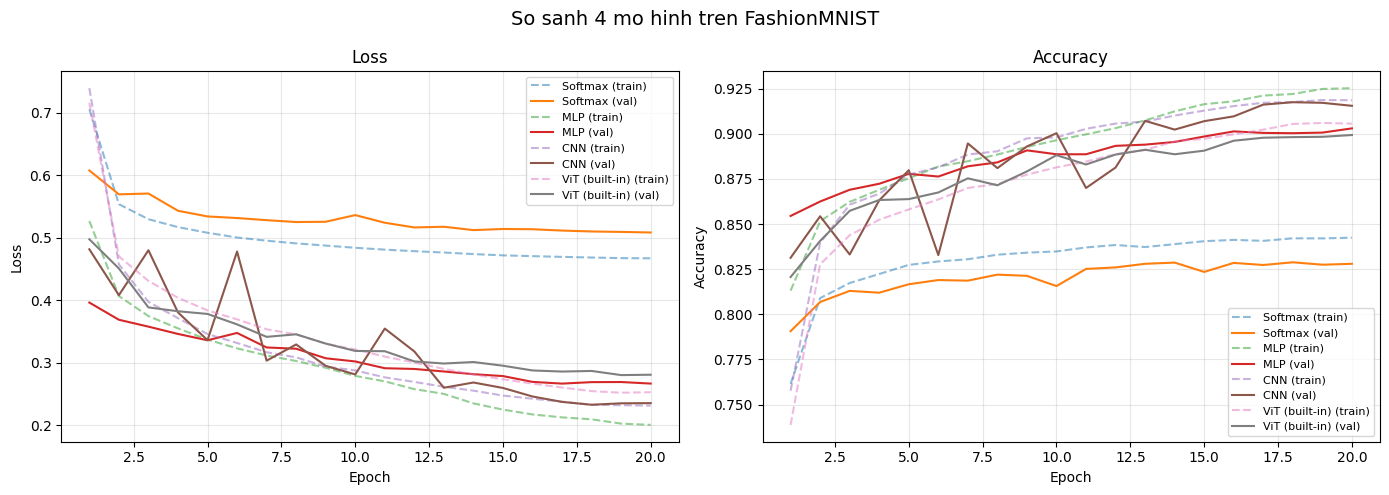

In [ ]:
# ============ BIEU DO SO SANH ============
def plot_training_curves(results, title='So sanh qua trinh huan luyen'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], '--', alpha=0.5, label=f'{name} (train)')
        axes[0].plot(epochs, hist['val_loss'], '-', label=f'{name} (val)')

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    for name, hist in results.items():
        epochs = range(1, len(hist['train_acc']) + 1)
        axes[1].plot(epochs, hist['train_acc'], '--', alpha=0.5, label=f'{name} (train)')
        axes[1].plot(epochs, hist['val_acc'], '-', label=f'{name} (val)')

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_curves(results, f'So sanh 4 mo hinh tren {DATASET_NAME}')

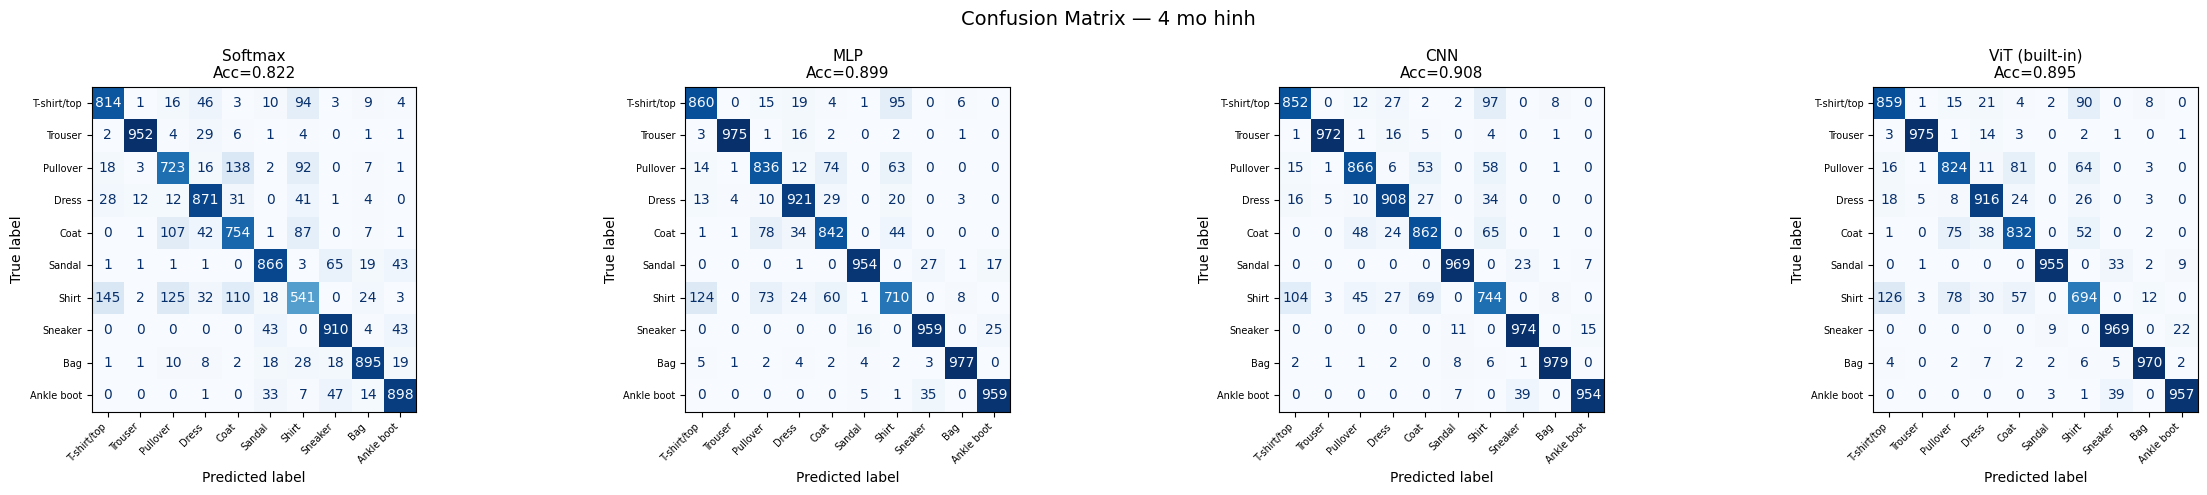

In [ ]:
# ============ CONFUSION MATRIX ============
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=data_info['class_names'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{name}\nAcc={res["test_acc"]:.3f}', fontsize=11)
    ax.set_xticklabels(data_info['class_names'], rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(data_info['class_names'], fontsize=7)
plt.suptitle('Confusion Matrix — 4 mo hinh', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============ BANG TONG HOP PHAN 1-2 ============
print("\n" + "="*80)
print(f"{'Mo hinh':20s} | {'Test Acc':>10s} | {'Test F1':>10s} | {'Params':>12s} | {'Time (s)':>10s}")
print("-"*80)
for name, res in test_results.items():
    print(f"{name:20s} | {res['test_acc']:>10.4f} | {res['test_f1']:>10.4f} | "
          f"{res['params']:>12,} | {res['time']:>10.1f}")
print("="*80)

print("\nNhan xet:")
print("- Softmax Regression: don gian nhat, accuracy thap nhat do chi co phep bien doi tuyen tinh.")
print("- MLP: cai thien so voi Softmax nho hidden layers, nhung khong tan dung cau truc khong gian.")
print("- CNN: tot nhat (hoac gan tot nhat) nho khai thac locality va weight sharing.")
print("- ViT: competitive voi CNN, nhung can nhieu tham so hon; tren dataset nho co the kem hon CNN.")


Mo hinh              |   Test Acc |    Test F1 |       Params |   Time (s)
--------------------------------------------------------------------------------
Softmax              |     0.8224 |     0.8213 |        7,850 |      270.4
MLP                  |     0.8993 |     0.8990 |      537,354 |      275.0
CNN                  |     0.9080 |     0.9081 |       94,410 |      294.0
ViT (built-in)       |     0.8951 |     0.8947 |      540,170 |      376.0

Nhan xet:
- Softmax Regression: don gian nhat, accuracy thap nhat do chi co phep bien doi tuyen tinh.
- MLP: cai thien so voi Softmax nho hidden layers, nhung khong tan dung cau truc khong gian.
- CNN: tot nhat (hoac gan tot nhat) nho khai thac locality va weight sharing.
- ViT: competitive voi CNN, nhung can nhieu tham so hon; tren dataset nho co the kem hon CNN.


---
## 5. Phan 3 — Tu hien thuc TransformerEncoder va ViT

Tu viet Multi-Head Self-Attention va TransformerEncoder tu cac phep toan co ban
(Linear, LayerNorm, einsum). **Khong dung** `nn.TransformerEncoderLayer` hoac `nn.TransformerEncoder`.

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self Attention tu hien thuc tu phep toan co ban."""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Q, K, V projections
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        H = self.num_heads
        d = self.head_dim

        # Tinh Q, K, V va reshape thanh multi-head
        Q = self.W_q(x).reshape(B, N, H, d).permute(0, 2, 1, 3)  # (B, H, N, d)
        K = self.W_k(x).reshape(B, N, H, d).permute(0, 2, 1, 3)
        V = self.W_v(x).reshape(B, N, H, d).permute(0, 2, 1, 3)

        # Scaled Dot-Product Attention: attn = softmax(Q @ K^T / sqrt(d)) @ V
        attn_scores = torch.einsum('bhid,bhjd->bhij', Q, K) * self.scale
        attn_probs = F.softmax(attn_scores, dim=-1)
        attn_probs = self.attn_dropout(attn_probs)

        out = torch.einsum('bhij,bhjd->bhid', attn_probs, V)
        out = out.permute(0, 2, 1, 3).reshape(B, N, D)  # Concat heads
        out = self.W_o(out)
        return out


class CustomTransformerBlock(nn.Module):
    """Mot khoi Transformer Encoder tu hien thuc (Pre-Norm)."""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # Pre-norm + residual
        x = x + self.mlp(self.norm2(x))   # Pre-norm + residual
        return x


class CustomTransformerEncoder(nn.Module):
    """Stack nhieu khoi Transformer."""
    def __init__(self, embed_dim, num_heads, mlp_dim, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            CustomTransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class ViT_Custom(nn.Module):
    """ViT dung khoi TransformerEncoder tu hien thuc."""
    def __init__(self, in_channels, img_size, num_classes,
                 patch_size=7, embed_dim=128, num_heads=4,
                 num_layers=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        self.patch_embed = nn.Unfold(
            kernel_size=patch_size, stride=patch_size)
        self.linear_proj = nn.Linear(patch_dim, embed_dim)

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # Dung khoi TU XAY
        self.transformer = CustomTransformerEncoder(
            embed_dim, num_heads, mlp_dim, num_layers, dropout)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).transpose(1, 2)
        x = self.linear_proj(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.transformer(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x

model_test = ViT_Custom(data_info['in_channels'], data_info['img_size'],
                         data_info['num_classes'])
print(f"ViT (custom) — Tong tham so: {sum(p.numel() for p in model_test.parameters()):,}")

ViT (custom) — Tong tham so: 540,170


In [ ]:
# ============ HUAN LUYEN ViT CUSTOM ============
print("="*60)
print("Huan luyen ViT (custom TransformerEncoder)")
print("="*60)
model_vit_custom = ViT_Custom(
    data_info['in_channels'], data_info['img_size'], data_info['num_classes'])
results['ViT (custom)'] = train_model(
    model_vit_custom, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

Huan luyen ViT (custom TransformerEncoder)
  Epoch [ 1/20] Train Loss: 0.6960 | Train Acc: 0.7448 | Val Loss: 0.4883 | Val Acc: 0.8243
  Epoch [ 5/20] Train Loss: 0.3773 | Train Acc: 0.8625 | Val Loss: 0.3666 | Val Acc: 0.8645
  Epoch [10/20] Train Loss: 0.3158 | Train Acc: 0.8831 | Val Loss: 0.3180 | Val Acc: 0.8787
  Epoch [15/20] Train Loss: 0.2667 | Train Acc: 0.9005 | Val Loss: 0.2886 | Val Acc: 0.8933
  Epoch [20/20] Train Loss: 0.2421 | Train Acc: 0.9096 | Val Loss: 0.2794 | Val Acc: 0.8970
  Done! Time: 402.5s | Best Val Acc: 0.8977


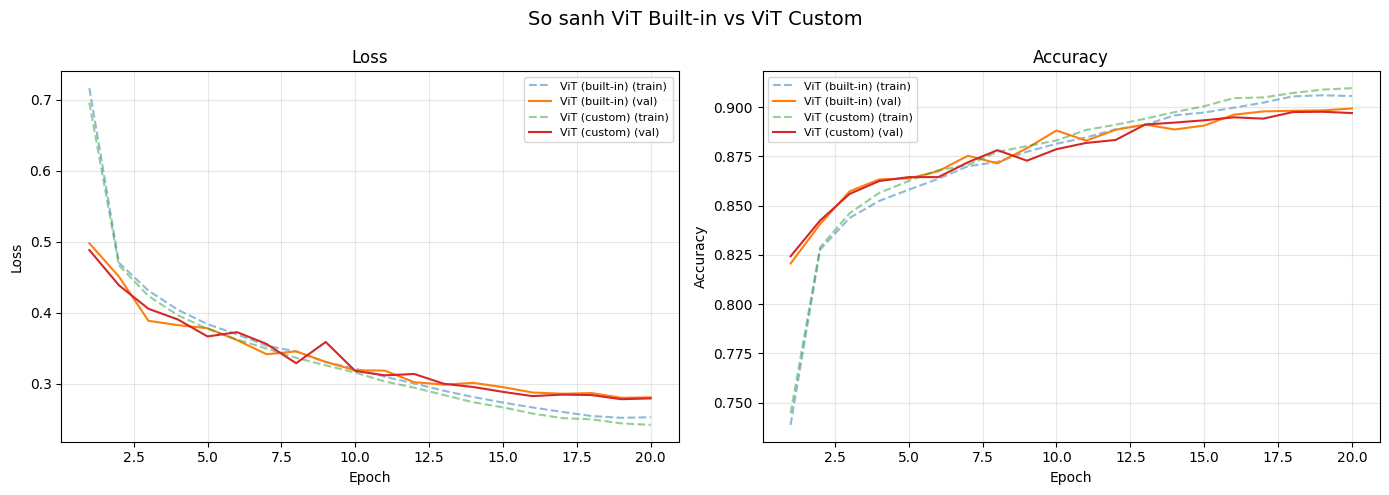


Mo hinh              |   Test Acc |    Test F1 |   Time (s)
------------------------------------------------------------
ViT (built-in)       |     0.8951 |     0.8947 |      376.0
ViT (custom)         |     0.8960 |     0.8957 |      402.5

Nhan xet:
- Hai phien ban ViT nen cho ket qua tuong duong vi cung kien truc.
- Su khac biet nho (neu co) do random initialization va numerical precision.
- Khoi tu xay giup hieu ro co che attention ben trong Transformer.


In [ ]:
# ============ SO SANH ViT BUILT-IN vs ViT CUSTOM ============
vit_comparison = {
    'ViT (built-in)': results['ViT (built-in)'],
    'ViT (custom)': results['ViT (custom)']
}
plot_training_curves(vit_comparison, 'So sanh ViT Built-in vs ViT Custom')

# Test ViT Custom
test_loss, test_acc, preds, labels = evaluate(
    model_vit_custom, test_loader, criterion, device)
f1 = f1_score(labels, preds, average='macro')
print(f"\n{'Mo hinh':20s} | {'Test Acc':>10s} | {'Test F1':>10s} | {'Time (s)':>10s}")
print("-"*60)
for name in ['ViT (built-in)', 'ViT (custom)']:
    if name == 'ViT (custom)':
        print(f"{name:20s} | {test_acc:>10.4f} | {f1:>10.4f} | "
              f"{results[name]['total_time']:>10.1f}")
    else:
        r = test_results[name]
        print(f"{name:20s} | {r['test_acc']:>10.4f} | {r['test_f1']:>10.4f} | "
              f"{results[name]['total_time']:>10.1f}")

print("\nNhan xet:")
print("- Hai phien ban ViT nen cho ket qua tuong duong vi cung kien truc.")
print("- Su khac biet nho (neu co) do random initialization va numerical precision.")
print("- Khoi tu xay giup hieu ro co che attention ben trong Transformer.")

---
## 6. Phan 4 — Cac kien truc ket hop va cach embed anh khac nhau

Trien khai 3 cach:
1. **CNN + Transformer**: CNN backbone -> Transformer encoder
2. **Overlapping Patch Embedding**: patch co overlap
3. **Spatial token (HxW as tokens)**: moi vi tri spatial la 1 token

In [ ]:
# ============ 4.1: CNN + Transformer ============
class CNN_Transformer(nn.Module):
    """
    CNN backbone trich dac trung -> reshape thanh sequence -> Transformer -> classify.
    """
    def __init__(self, in_channels, img_size, num_classes,
                 embed_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        # CNN backbone: extract spatial features
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 2
        num_tokens = feat_size * feat_size

        self.proj = nn.Linear(64, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_tokens + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim*2, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.cnn(x)                     # (B, 64, H', W')
        x = x.flatten(2).transpose(1, 2)    # (B, H'*W', 64)
        x = self.proj(x)                    # (B, N, embed_dim)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

print("CNN+Transformer params:",
      sum(p.numel() for p in CNN_Transformer(
          data_info['in_channels'], data_info['img_size'],
          data_info['num_classes']).parameters()))

CNN+Transformer params: 319178


/tmp/ipykernel_1977/44468406.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
# ============ 4.2: Overlapping Patch Embedding ============
class ViT_OverlapPatch(nn.Module):
    """
    ViT voi overlapping patch: dung Conv2d voi stride < kernel_size.
    """
    def __init__(self, in_channels, img_size, num_classes,
                 patch_size=7, stride=4, embed_dim=128,
                 num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        # Conv2d tao overlapping patches
        self.patch_conv = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=stride,
            padding=patch_size // 2)

        feat_size = (img_size + 2 * (patch_size // 2) - patch_size) // stride + 1
        num_patches = feat_size * feat_size

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim*2, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_conv(x)              # (B, embed_dim, H', W')
        x = x.flatten(2).transpose(1, 2)    # (B, N, embed_dim)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

print("ViT Overlap Patch params:",
      sum(p.numel() for p in ViT_OverlapPatch(
          data_info['in_channels'], data_info['img_size'],
          data_info['num_classes']).parameters()))

ViT Overlap Patch params: 544394


/tmp/ipykernel_1977/2148855568.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
# ============ 4.3: Spatial Token (HxW as tokens) ============
class ViT_SpatialToken(nn.Module):
    """
    Coi moi vi tri spatial (pixel) tren feature map la mot token.
    Token dim = so channels.
    """
    def __init__(self, in_channels, img_size, num_classes,
                 embed_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        num_tokens = img_size * img_size
        self.proj = nn.Linear(in_channels, embed_dim)

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_tokens + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim*2, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        # x: (B, C, H, W) -> (B, H*W, C)
        x = x.flatten(2).transpose(1, 2)
        x = self.proj(x)  # (B, H*W, embed_dim)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

print("ViT Spatial Token params:",
      sum(p.numel() for p in ViT_SpatialToken(
          data_info['in_channels'], data_info['img_size'],
          data_info['num_classes']).parameters()))

ViT Spatial Token params: 367370


/tmp/ipykernel_1977/2012576125.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
# ============ HUAN LUYEN CAC KIEN TRUC PHAN 4 ============
part4_models = {
    'CNN+Transformer': CNN_Transformer(
        data_info['in_channels'], data_info['img_size'], data_info['num_classes']),
    'ViT Overlap Patch': ViT_OverlapPatch(
        data_info['in_channels'], data_info['img_size'], data_info['num_classes']),
    'ViT Spatial Token': ViT_SpatialToken(
        data_info['in_channels'], data_info['img_size'], data_info['num_classes']),
}

part4_results = {}
for name, model in part4_models.items():
    print("="*60)
    print(f"Huan luyen: {name}")
    print("="*60)
    part4_results[name] = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)
    print()

Huan luyen: CNN+Transformer


/tmp/ipykernel_1977/44468406.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_1977/2148855568.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_1977/2012576125.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  Epoch [ 1/20] Train Loss: 0.7102 | Train Acc: 0.7381 | Val Loss: 0.4457 | Val Acc: 0.8442
  Epoch [ 5/20] Train Loss: 0.3106 | Train Acc: 0.8871 | Val Loss: 0.3319 | Val Acc: 0.8835
  Epoch [10/20] Train Loss: 0.2374 | Train Acc: 0.9124 | Val Loss: 0.2569 | Val Acc: 0.9102
  Epoch [15/20] Train Loss: 0.1820 | Train Acc: 0.9330 | Val Loss: 0.2261 | Val Acc: 0.9215
  Epoch [20/20] Train Loss: 0.1563 | Train Acc: 0.9428 | Val Loss: 0.2111 | Val Acc: 0.9305
  Done! Time: 547.4s | Best Val Acc: 0.9305

Huan luyen: ViT Overlap Patch
  Epoch [ 1/20] Train Loss: 0.7436 | Train Acc: 0.7237 | Val Loss: 0.4856 | Val Acc: 0.8218
  Epoch [ 5/20] Train Loss: 0.3794 | Train Acc: 0.8610 | Val Loss: 0.3486 | Val Acc: 0.8763
  Epoch [10/20] Train Loss: 0.3118 | Train Acc: 0.8847 | Val Loss: 0.3137 | Val Acc: 0.8847
  Epoch [15/20] Train Loss: 0.2612 | Train Acc: 0.9028 | Val Loss: 0.2658 | Val Acc: 0.9038
  Epoch [20/20] Train Loss: 0.2326 | Train Acc: 0.9134 | Val Loss: 0.2613 | Val Acc: 0.9073
  Don

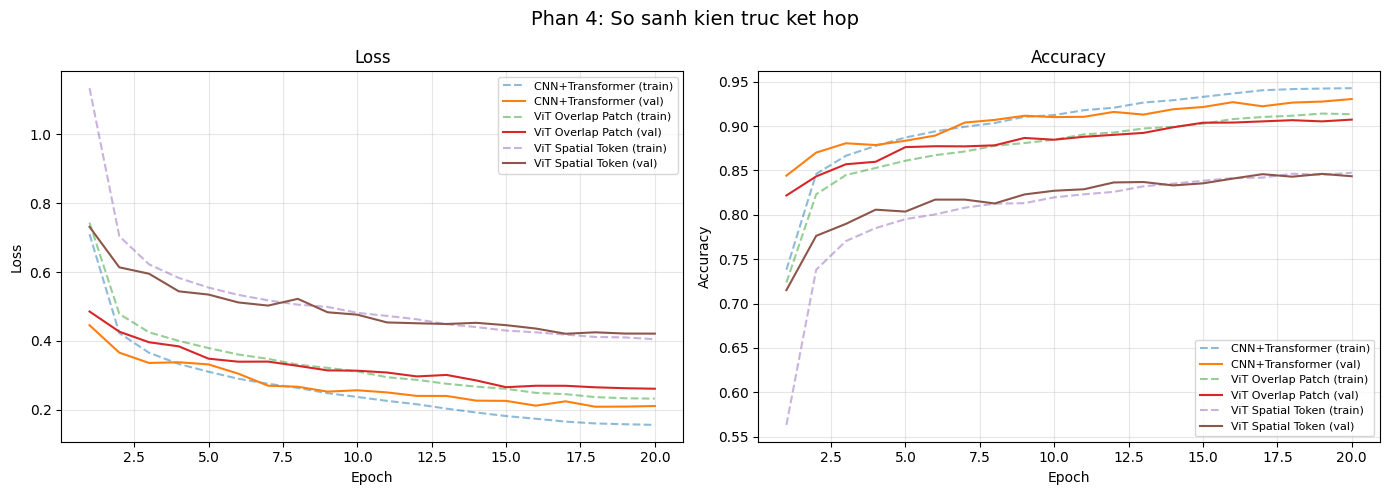


Kien truc                 |   Test Acc |    Test F1 |       Params |     Time
---------------------------------------------------------------------------
CNN+Transformer           |     0.9199 |     0.9196 |      319,178 |   547.4s
ViT Overlap Patch         |     0.9007 |     0.9002 |      544,394 |   377.0s
ViT Spatial Token         |     0.8450 |     0.8437 |      367,370 |  3077.7s

Nhan xet:
- CNN+Transformer: ket hop uu diem CNN (local feature) + Transformer (global attention).
- Overlap Patch: tang so luong tokens, moi patch co thong tin lien ke.
- Spatial Token: moi pixel la mot token, sequence dai, chi phi attention cao.


In [ ]:
# ============ SO SANH PHAN 4 ============
plot_training_curves(part4_results,
                     'Phan 4: So sanh kien truc ket hop')

print(f"\n{'Kien truc':25s} | {'Test Acc':>10s} | {'Test F1':>10s} | {'Params':>12s} | {'Time':>8s}")
print("-"*75)
for name, model in part4_models.items():
    test_loss, test_acc, preds, labels_arr = evaluate(
        model, test_loader, criterion, device)
    f1 = f1_score(labels_arr, preds, average='macro')
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:25s} | {test_acc:>10.4f} | {f1:>10.4f} | "
          f"{params:>12,} | {part4_results[name]['total_time']:>7.1f}s")

print("\nNhan xet:")
print("- CNN+Transformer: ket hop uu diem CNN (local feature) + Transformer (global attention).")
print("- Overlap Patch: tang so luong tokens, moi patch co thong tin lien ke.")
print("- Spatial Token: moi pixel la mot token, sequence dai, chi phi attention cao.")

---
## 7. Phan 5 — Mo hinh phan loai dua tren LSTM/GRU

Bieu dien anh thanh chuoi (sequence) va phan loai bang LSTM/GRU.

**Ba cach bieu dien chuoi:**
1. Moi **hang** cua anh la mot buoc thoi gian
2. Moi **cot** cua anh la mot buoc thoi gian
3. Moi **patch** (chia anh thanh o) la mot buoc thoi gian

In [ ]:
class RNN_ImageClassifier(nn.Module):
    """
    Phan loai anh bang LSTM/GRU.

    seq_mode:
        'row'   : moi hang la 1 timestep (seq_len=H, input_dim=W*C)
        'col'   : moi cot la 1 timestep (seq_len=W, input_dim=H*C)
        'patch' : moi patch la 1 timestep

    rnn_type: 'LSTM' hoac 'GRU'
    """
    def __init__(self, in_channels, img_size, num_classes,
                 hidden_dim=128, num_layers=2, rnn_type='LSTM',
                 seq_mode='row', patch_size=7, dropout=0.3,
                 bidirectional=True):
        super().__init__()
        self.seq_mode = seq_mode
        self.img_size = img_size
        self.in_channels = in_channels
        self.patch_size = patch_size

        # Xac dinh input_dim va seq_len tuy theo seq_mode
        if seq_mode == 'row':
            input_dim = img_size * in_channels
        elif seq_mode == 'col':
            input_dim = img_size * in_channels
        elif seq_mode == 'patch':
            input_dim = in_channels * patch_size * patch_size
        else:
            raise ValueError(f"Unknown seq_mode: {seq_mode}")

        RNN_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = RNN_cls(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        fc_input = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fc_input, num_classes)
        )

    def _to_sequence(self, x):
        """Chuyen anh thanh sequence tuy theo mode."""
        B, C, H, W = x.shape
        if self.seq_mode == 'row':
            # (B, C, H, W) -> (B, H, C*W)
            x = x.permute(0, 2, 1, 3).reshape(B, H, C * W)
        elif self.seq_mode == 'col':
            # (B, C, H, W) -> (B, W, C*H)
            x = x.permute(0, 3, 1, 2).reshape(B, W, C * H)
        elif self.seq_mode == 'patch':
            # Chia thanh patches
            ps = self.patch_size
            x = x.unfold(2, ps, ps).unfold(3, ps, ps)
            # (B, C, nH, nW, ps, ps)
            nH, nW = x.shape[2], x.shape[3]
            x = x.contiguous().reshape(B, C, nH * nW, ps * ps)
            x = x.permute(0, 2, 1, 3).reshape(B, nH * nW, C * ps * ps)
        return x

    def forward(self, x):
        x = self._to_sequence(x)  # (B, seq_len, input_dim)
        output, _ = self.rnn(x)   # (B, seq_len, hidden_dim*num_directions)
        # Lay output cuoi cung
        x = output[:, -1, :]
        return self.classifier(x)

# Test
for mode in ['row', 'col', 'patch']:
    m = RNN_ImageClassifier(
        data_info['in_channels'], data_info['img_size'],
        data_info['num_classes'], seq_mode=mode)
    print(f"LSTM ({mode}) — Params: {sum(p.numel() for p in m.parameters()):,}")

LSTM (row) — Params: 559,626
LSTM (col) — Params: 559,626
LSTM (patch) — Params: 581,130


In [ ]:
# ============ HUAN LUYEN CAC MO HINH RNN ============
part5_configs = [
    {'name': 'LSTM (row)',  'rnn_type': 'LSTM', 'seq_mode': 'row'},
    {'name': 'LSTM (col)',  'rnn_type': 'LSTM', 'seq_mode': 'col'},
    {'name': 'LSTM (patch)','rnn_type': 'LSTM', 'seq_mode': 'patch'},
    {'name': 'GRU (row)',   'rnn_type': 'GRU',  'seq_mode': 'row'},
]

part5_models = {}
part5_results = {}

for cfg in part5_configs:
    print("="*60)
    print(f"Huan luyen: {cfg['name']}")
    print("="*60)
    model = RNN_ImageClassifier(
        data_info['in_channels'], data_info['img_size'],
        data_info['num_classes'],
        rnn_type=cfg['rnn_type'],
        seq_mode=cfg['seq_mode'])
    part5_results[cfg['name']] = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)
    part5_models[cfg['name']] = model
    print()

Huan luyen: LSTM (row)
  Epoch [ 1/20] Train Loss: 0.7916 | Train Acc: 0.7059 | Val Loss: 0.5212 | Val Acc: 0.8113
  Epoch [ 5/20] Train Loss: 0.3580 | Train Acc: 0.8693 | Val Loss: 0.3473 | Val Acc: 0.8728
  Epoch [10/20] Train Loss: 0.2812 | Train Acc: 0.8964 | Val Loss: 0.3026 | Val Acc: 0.8958
  Epoch [15/20] Train Loss: 0.2244 | Train Acc: 0.9180 | Val Loss: 0.2667 | Val Acc: 0.9058
  Epoch [20/20] Train Loss: 0.1914 | Train Acc: 0.9311 | Val Loss: 0.2611 | Val Acc: 0.9053
  Done! Time: 306.7s | Best Val Acc: 0.9058

Huan luyen: LSTM (col)
  Epoch [ 1/20] Train Loss: 0.8665 | Train Acc: 0.6777 | Val Loss: 0.5883 | Val Acc: 0.7870
  Epoch [ 5/20] Train Loss: 0.3941 | Train Acc: 0.8552 | Val Loss: 0.3916 | Val Acc: 0.8598
  Epoch [10/20] Train Loss: 0.3108 | Train Acc: 0.8858 | Val Loss: 0.3215 | Val Acc: 0.8825
  Epoch [15/20] Train Loss: 0.2589 | Train Acc: 0.9053 | Val Loss: 0.3094 | Val Acc: 0.8882
  Epoch [20/20] Train Loss: 0.2349 | Train Acc: 0.9134 | Val Loss: 0.2945 | Val A

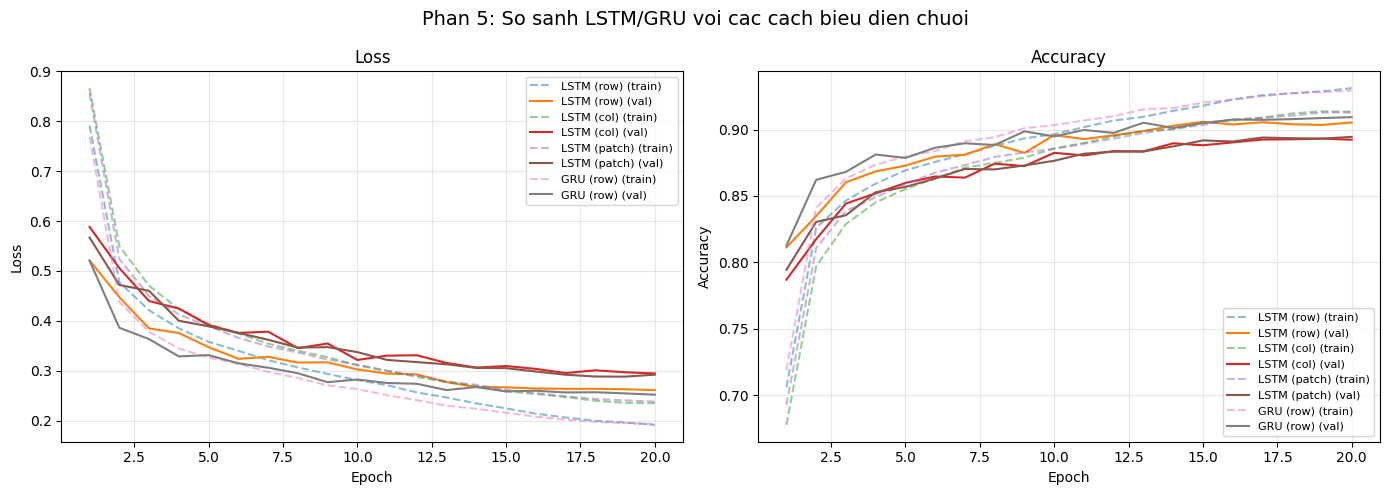


Mo hinh              |   Test Acc |    Test F1 |       Params |     Time
----------------------------------------------------------------------
LSTM (row)           |     0.9028 |     0.9025 |      559,626 |   306.7s
LSTM (col)           |     0.8913 |     0.8910 |      559,626 |   304.2s
LSTM (patch)         |     0.8846 |     0.8843 |      581,130 |   304.8s
GRU (row)            |     0.9086 |     0.9084 |      420,362 |   308.0s

Nhan xet:
- Row-based: moi hang la timestep, tu nhien nhat cho anh scan tu tren xuong.
- Col-based: tuong tu nhung scan theo cot.
- Patch-based: RNN nhan dau vao 2D -> ket qua tot hon.
- GRU thuong nhanh hon LSTM (it tham so hon) nhung ket qua tuong duong.


In [ ]:
# ============ SO SANH PHAN 5 ============
plot_training_curves(part5_results,
                     'Phan 5: So sanh LSTM/GRU voi cac cach bieu dien chuoi')

print(f"\n{'Mo hinh':20s} | {'Test Acc':>10s} | {'Test F1':>10s} | {'Params':>12s} | {'Time':>8s}")
print("-"*70)
for name, model in part5_models.items():
    test_loss, test_acc, preds, labels_arr = evaluate(
        model, test_loader, criterion, device)
    f1 = f1_score(labels_arr, preds, average='macro')
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:20s} | {test_acc:>10.4f} | {f1:>10.4f} | "
          f"{params:>12,} | {part5_results[name]['total_time']:>7.1f}s")

print("\nNhan xet:")
print("- Row-based: moi hang la timestep, tu nhien nhat cho anh scan tu tren xuong.")
print("- Col-based: tuong tu nhung scan theo cot.")
print("- Patch-based: RNN nhan dau vao 2D -> ket qua tot hon.")
print("- GRU thuong nhanh hon LSTM (it tham so hon) nhung ket qua tuong duong.")

---
## 8. Tong hop ket qua & So sanh toan bo

In [ ]:
# ============ BANG TONG HOP TAT CA MO HINH ============
all_models = {}
all_models.update(models_dict)            # Phan 1-2
all_models['ViT (custom)'] = model_vit_custom  # Phan 3
all_models.update(part4_models)           # Phan 4
all_models.update(part5_models)           # Phan 5

all_results_names = {}
all_results_names.update(results)
all_results_names.update(part4_results)
all_results_names.update(part5_results)

print("\n" + "="*90)
print(f"TONG HOP KET QUA — {DATASET_NAME}")
print("="*90)
print(f"{'Phan':>5s} | {'Mo hinh':25s} | {'Test Acc':>10s} | {'Test F1':>10s} | "
      f"{'Params':>12s} | {'Time':>8s}")
print("-"*90)

part_map = {
    'Softmax': '1-2', 'MLP': '1-2', 'CNN': '1-2', 'ViT (built-in)': '1-2',
    'ViT (custom)': '3',
    'CNN+Transformer': '4', 'ViT Overlap Patch': '4', 'ViT Spatial Token': '4',
    'LSTM (row)': '5', 'LSTM (col)': '5', 'LSTM (patch)': '5', 'GRU (row)': '5'
}

for name, model in all_models.items():
    test_loss, test_acc, preds, labels_arr = evaluate(
        model, test_loader, criterion, device)
    f1 = f1_score(labels_arr, preds, average='macro')
    params = sum(p.numel() for p in model.parameters())
    t = all_results_names.get(name, {}).get('total_time', 0)
    part = part_map.get(name, '?')
    print(f"{part:>5s} | {name:25s} | {test_acc:>10.4f} | {f1:>10.4f} | "
          f"{params:>12,} | {t:>7.1f}s")

print("="*90)


TONG HOP KET QUA — FashionMNIST
 Phan | Mo hinh                   |   Test Acc |    Test F1 |       Params |     Time
------------------------------------------------------------------------------------------
  1-2 | Softmax                   |     0.8224 |     0.8213 |        7,850 |   270.4s
  1-2 | MLP                       |     0.8993 |     0.8990 |      537,354 |   275.0s
  1-2 | CNN                       |     0.9080 |     0.9081 |       94,410 |   294.0s
  1-2 | ViT (built-in)            |     0.8951 |     0.8947 |      540,170 |   376.0s
    3 | ViT (custom)              |     0.8960 |     0.8957 |      540,170 |   402.5s
    4 | CNN+Transformer           |     0.9199 |     0.9196 |      319,178 |   547.4s
    4 | ViT Overlap Patch         |     0.9007 |     0.9002 |      544,394 |   377.0s
    4 | ViT Spatial Token         |     0.8450 |     0.8437 |      367,370 |  3077.7s
    5 | LSTM (row)                |     0.9028 |     0.9025 |      559,626 |   306.7s
    5 | LSTM (co

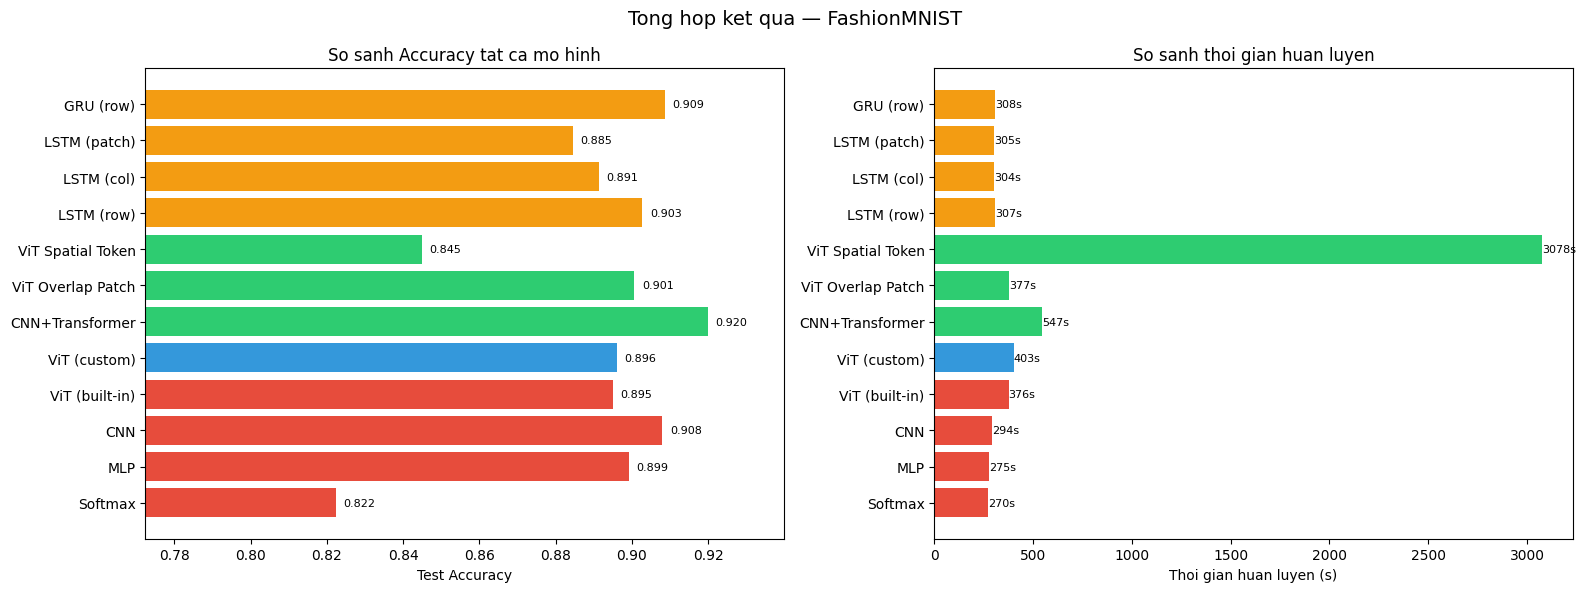

In [ ]:
# ============ BIEU DO TONG HOP ============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Test Accuracy
names = []
accs = []
times = []
for name, model in all_models.items():
    _, acc, _, _ = evaluate(model, test_loader, criterion, device)
    names.append(name)
    accs.append(acc)
    times.append(all_results_names.get(name, {}).get('total_time', 0))

colors = ['#e74c3c'] * 4 + ['#3498db'] + ['#2ecc71'] * 3 + ['#f39c12'] * 4
axes[0].barh(names, accs, color=colors)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('So sanh Accuracy tat ca mo hinh')
axes[0].set_xlim(min(accs) - 0.05, max(accs) + 0.02)
for i, v in enumerate(accs):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# Bar chart: Training Time
axes[1].barh(names, times, color=colors)
axes[1].set_xlabel('Thoi gian huan luyen (s)')
axes[1].set_title('So sanh thoi gian huan luyen')
for i, v in enumerate(times):
    axes[1].text(v + 0.5, i, f'{v:.0f}s', va='center', fontsize=8)

plt.suptitle(f'Tong hop ket qua — {DATASET_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============ NHAN XET TONG HOP ============
print("""
================================================================
                    NHAN XET TONG HOP
================================================================

  PHAN 1-2: So sanh 4 mo hinh co ban
  - Softmax < MLP < CNN ~ ViT (tren dataset nho)
  - CNN hieu qua nhat xet accuracy/params tren anh nho
  - ViT can nhieu data hon de phat huy uu diem

  PHAN 3: ViT tu xay vs ViT PyTorch built-in
  - Ket qua tuong duong -> khoi tu xay dung dan
  - Hieu sau hon co che self-attention

  PHAN 4: Kien truc ket hop
  - CNN+Transformer: ket hop local + global features
  - Overlap patch: them context o bien
  - Spatial token: chi phi cao nhung giu full spatial info

  PHAN 5: LSTM/GRU
  - Row/Col: cach bieu dien don gian, hieu qua vua phai
  - Patch: RNN nhan dau vao 2D -> ket qua tot hon
  - GRU nhanh hon LSTM, accuracy tuong duong

================================================================
""")


                    NHAN XET TONG HOP

  PHAN 1-2: So sanh 4 mo hinh co ban
  - Softmax < MLP < CNN ~ ViT (tren dataset nho)
  - CNN hieu qua nhat xet accuracy/params tren anh nho
  - ViT can nhieu data hon de phat huy uu diem

  PHAN 3: ViT tu xay vs ViT PyTorch built-in
  - Ket qua tuong duong -> khoi tu xay dung dan
  - Hieu sau hon co che self-attention

  PHAN 4: Kien truc ket hop
  - CNN+Transformer: ket hop local + global features
  - Overlap patch: them context o bien
  - Spatial token: chi phi cao nhung giu full spatial info

  PHAN 5: LSTM/GRU
  - Row/Col: cach bieu dien don gian, hieu qua vua phai
  - Patch: RNN nhan dau vao 2D -> ket qua tot hon
  - GRU nhanh hon LSTM, accuracy tuong duong


